# Task 1: Potential problems in linear regression

This notebook contains investigations of 3 potential problems of fitting linear models, sourced from section 3.3.3 in the EDS233 course textbook: [An Introduction to Statistical Learning with applications in Python](https://www.statlearning.com/). The section covers six common issues when fitting a linear model, and here I have selected **correlation of error terms**, **high-leverage points**, and **outliers**.

Additionally, in order to investigate these issues further, I used Claude to write Python code that:

- generates synthetic data that clearly illustrates the issue
- produces plots making the issue visually clear
- where applicable, produces additional plots showing how the issue can be addressed.

This was completed as part of Assignment 2.

In [3]:
# Load necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Issue 1: Correlation of error terms

### Explanation

The standard errors of regression coefficients are calculated under the assumption that error terms are uncorrelated. However, when they *are* correlated but not accounted for, they produce standard errors that understimate the true standard error. This creates an unwarrated sense of confidence in the model (for example, it can narrow the confidence interval). This issue can often occur in time series data, where observations that are proximate to one another in time may have similar errors, making them correlated. A way to detect this is to plot residuals against time – if the residuals show a pattern where observations next to each other tend to be all positive or all negative, that may be a sign of correlated error terms.

#### Question
One aspect that the text did not clarify for me is how to actually address the issue of correlation of error terms. From my investigations, I found that adding a time-lagged dependent variable can help reduce the effects of correlation, because it then models how past observations influence the current one. I think it is also important to simply be aware of potential correlation between error terms, and address it in interpretations of the model.

### Plots (code generated by Claude)

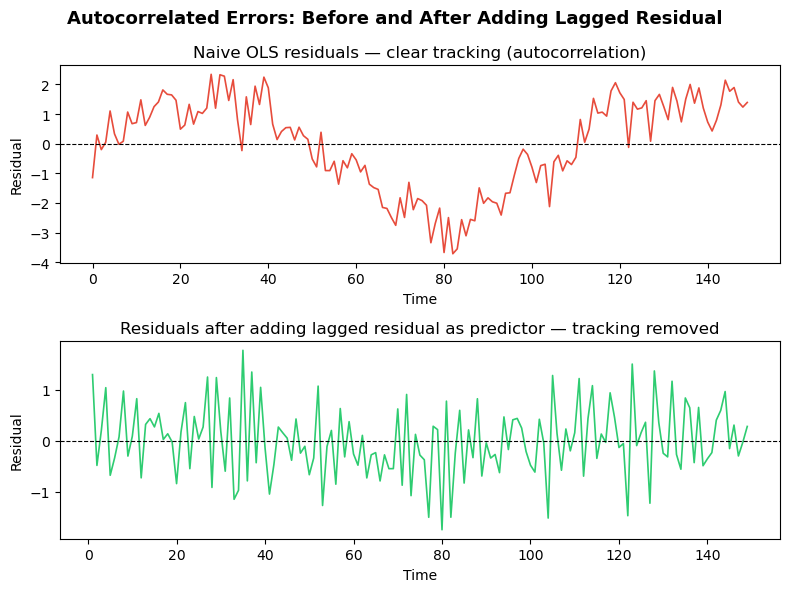

In [5]:
# Set random seed
np.random.seed(0)
n = 150
t = np.arange(n)

##  Generate synthetic data
# A slow-moving confound (e.g. temperature, economic cycle) that we don't observe
hidden = np.cumsum(np.random.normal(0, 0.3, n))  # random walk

# Observed predictor
x = t / 10 + np.random.normal(0, 0.5, n)

# y depends on x AND the hidden trend → errors will be autocorrelated
y = 2 * x + 0.8 * hidden + np.random.normal(0, 0.5, n)

# ── Naive OLS (ignores the hidden trend) ─────────────────────────────────────
slope, intercept, *_ = stats.linregress(x, y)
resid = y - (intercept + slope * x)

# ── Fix: add lagged residual as a proxy for the hidden trend ─────────────────
lag = 1
x_lag = resid[:-lag]          # lagged residual
x_cur = x[lag:]
y_cur = y[lag:]

X = np.column_stack([x_cur, x_lag])
coef, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(y_cur)), X]), y_cur, rcond=None)
resid_fixed = y_cur - (coef[0] + coef[1] * x_cur + coef[2] * x_lag)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=False)
fig.suptitle("Autocorrelated Errors: Before and After Adding Lagged Residual",
             fontsize=13, fontweight="bold")

ax1.plot(t, resid, color="#e74c3c", linewidth=1.2)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Naive OLS residuals — clear tracking (autocorrelation)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Residual")

ax2.plot(t[lag:], resid_fixed, color="#2ecc71", linewidth=1.2)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Residuals after adding lagged residual as predictor — tracking removed")
ax2.set_xlabel("Time")
ax2.set_ylabel("Residual")

plt.tight_layout()

These two plots demonstrate how adding a time-lagged predictor variable can help address the issue of correlated error terms. In the top plot (red line) it is very clear that there is a relationship in residuals that are near each other in time – those that are positive tend to be near those that are also positive, and those that are negative tend to be near those that are negative. In the lower plot (green line), we don't see that pattern anymore. Residuals tend to oscillate between negative and positive after a time-lagged predictor variable is added. This change has helped address the issue of correlation between error terms.

## Issue 2: Outliers

### Explanation

An outlier is a point for which the true response variable *y* is far from the model's predicted response. Keeping or removing the outlier can change the models relationship between predictors and the response variable, but even when the slope doesn't change, outliers can negatively impact metrics such as RSE and R-squared. Therefore, outliers can alter model interpretation and accuracy if not addressed. 

Outliers can be detected by plotting residuals and seeing if there are any that are much greater than the others. However, this leads to the issue of determining what is actually "much greater". A way to decide this is by plotting the *studentized* residuals instead, which are equal to the residual divided by its estimated standard error. Once located, the issue of outliers can be addressed by simple removal if it is determined to be due to a collection error. However, it is also important to consider if maybe the outlier is a sign of a missing predictor.

#### Question

The text only discusses two reasons for outliers: a missing predictor or collection error. Are there other ways they can come about? Some answers I found fall into these two categories, but are more specific:

Collection errors
- Errors from data entry
- Errors from measurement (tools were not properly calibrated or were not operating correctly)
- Contamination of sample, where observations from different populations were included

Model errors
- Applying a linear model to data that is non-linear can make data points on the edge appear as outliers

True outliers
- Rare natural occurences during data collection could lead to genuinely extreme values

### Plots (code generated by Claude)

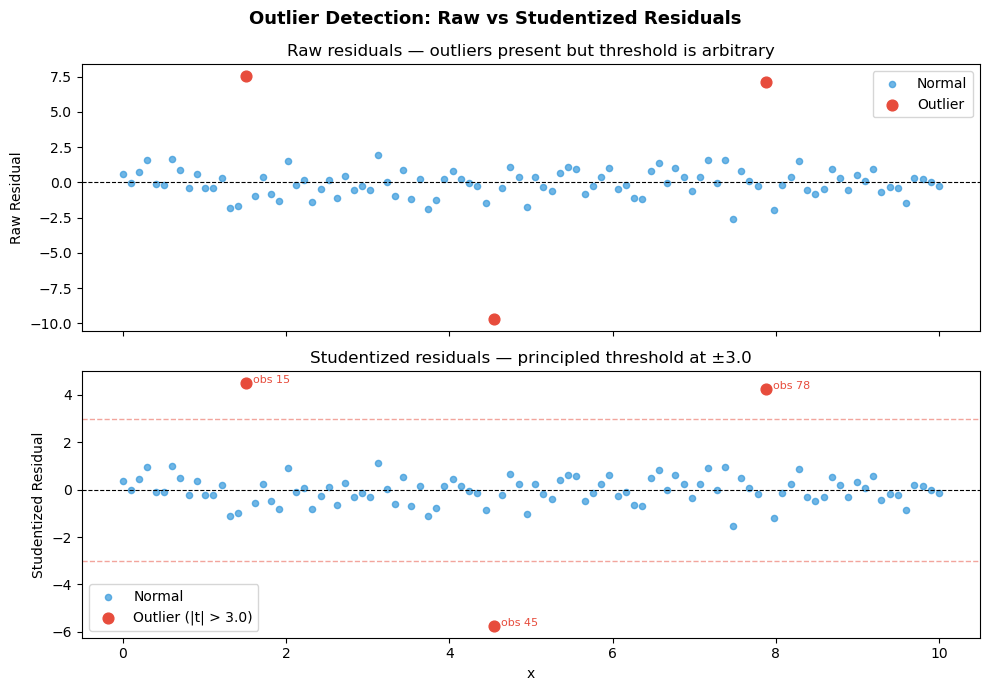

In [7]:
# Set random seed
np.random.seed(42)
n = 100
x = np.linspace(0, 10, n)
y = 2 * x + 1 + np.random.normal(0, 1, n)

# Inject a few outliers (unusual y values)
outlier_idx = [15, 45, 78]
y[outlier_idx] += [8, -9, 7]

# Fit OLS
slope, intercept, *_ = stats.linregress(x, y)
y_hat = intercept + slope * x
resid = y - y_hat

# Studentized residuals: resid / (s * sqrt(1 - h_ii))
# h_ii = leverage = 1/n + (x_i - x_bar)^2 / sum((x - x_bar)^2)
x_bar = x.mean()
ss_x = np.sum((x - x_bar) ** 2)
leverage = 1 / n + (x - x_bar) ** 2 / ss_x

p = 2  # intercept + slope
mse = np.sum(resid**2) / (n - p)
studentized = resid / np.sqrt(mse * (1 - leverage))

threshold = 3.0
is_outlier = np.abs(studentized) > threshold

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Outlier Detection: Raw vs Studentized Residuals", fontsize=13, fontweight="bold")

normal = ~is_outlier

ax1.scatter(x[normal], resid[normal], color="#3498db", s=20, alpha=0.7, label="Normal")
ax1.scatter(x[is_outlier], resid[is_outlier], color="#e74c3c", s=60, zorder=5, label="Outlier")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_ylabel("Raw Residual")
ax1.set_title("Raw residuals — outliers present but threshold is arbitrary")
ax1.legend()

ax2.scatter(x[normal], studentized[normal], color="#3498db", s=20, alpha=0.7, label="Normal")
ax2.scatter(x[is_outlier], studentized[is_outlier], color="#e74c3c", s=60, zorder=5, label=f"Outlier (|t| > {threshold})")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.axhline(threshold, color="#e74c3c", linewidth=1, linestyle="--", alpha=0.5)
ax2.axhline(-threshold, color="#e74c3c", linewidth=1, linestyle="--", alpha=0.5)
ax2.set_ylabel("Studentized Residual")
ax2.set_xlabel("x")
ax2.set_title(f"Studentized residuals — principled threshold at ±{threshold}")
ax2.legend()

for idx in outlier_idx:
    ax2.annotate(f"  obs {idx}", (x[idx], studentized[idx]), fontsize=8, color="#e74c3c")

plt.tight_layout()

The plots above represent the threshold that studentized residuals create, making identifying easier. In the top plot, studentized residuals were not calculated, and the red outliers can only be determined based on their relative, ambiguous distance from the rest of the residuals. On the bottom plot, calculating studentized residuals provides us with a threshold, and we can be certain that the red points are truly outliers in our dataset.

## Issue 3: High-leverage points

### Explanation

High-leverage points are similar to outliers, though they represent observations where the *x*-values are unusual, as opposed to *y*. Typically, removal of high-leverage points can have more substantial impact on the linear regression line than removing outliers. It is important to identify high-leverage points, as they can invalidate the entire model fit.

A way to determine high-leverage points is to find the predictors which are outside of the normal predictor range. However, this can pose challenges when there are multiple predictors in the model. For example, even if both Predictor 1 and Predictor 2 are within their own expected ranges, it is possible that their *combination* can be outside of the normal range of the data. A more substantial way of identifying leverage is by calculating the leverage statistic.

#### Question

I am curious why high-leverage points are more detrimental to model fit than outliers. After investigating further, I determined that high-leverage points may be worse because they are harder to identify: they typically have smaller residuals than what an outlier would have (since they force the line to pass through them). Another perspective is that the extreme x-values can change the actual slope of the regression line – affecting the modeled relationship – whereas outliers might simply shift the line up or down, changing only the intercept.

### Plots

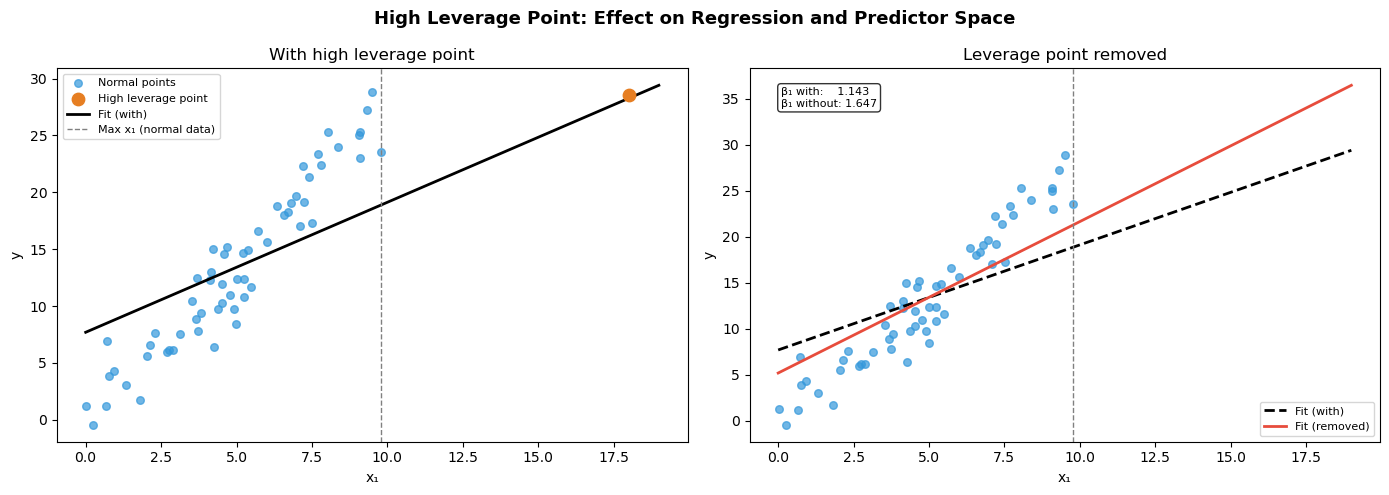

In [13]:
# Set random seed
np.random.seed(7)
n = 60

# Generate random data
x1 = np.random.uniform(0, 10, n)
x2 = 0.6 * x1 + np.random.normal(0, 1, n)
y = 1.5 * x1 + 2.0 * x2 + np.random.normal(0, 1.5, n)

lev_x1 = 18.0
lev_x2 = 0.6 * lev_x1 + np.random.normal(0, 0.3)
lev_y  = 1.5 * lev_x1 + 2.0 * lev_x2 - 20

x1_full = np.append(x1, lev_x1)
x2_full = np.append(x2, lev_x2)
y_full  = np.append(y,  lev_y)

# Define functions to return coefficients?
def ols_fit(xa, xb, ya):
    X = np.column_stack([np.ones(len(ya)), xa, xb])
    coef, *_ = np.linalg.lstsq(X, ya, rcond=None)
    return coef


def predict_line(coef, x1_range, x2_mean):
    return coef[0] + coef[1] * x1_range + coef[2] * x2_mean


coef_full    = ols_fit(x1_full, x2_full, y_full)
coef_removed = ols_fit(x1,      x2,      y)

x1_line         = np.linspace(0, 19, 200)
x2_mean_full    = x2_full.mean()
x2_mean_removed = x2.mean()

# Plot!
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("High Leverage Point: Effect on Regression and Predictor Space",
             fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(x1, y, color="#3498db", s=30, alpha=0.7, label="Normal points")
ax.scatter(lev_x1, lev_y, color="#e67e22", s=80, zorder=5, label="High leverage point")
ax.plot(x1_line, predict_line(coef_full, x1_line, x2_mean_full),
        color="black", linewidth=2, label="Fit (with)")
ax.axvline(x1.max(), color="grey", linewidth=1, linestyle="--", label="Max x₁ (normal data)")
ax.set_xlabel("x₁"); ax.set_ylabel("y")
ax.set_title("With high leverage point")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(x1, y, color="#3498db", s=30, alpha=0.7)
ax.plot(x1_line, predict_line(coef_full,    x1_line, x2_mean_full),
        color="black",   linewidth=2, linestyle="--", label="Fit (with)")
ax.plot(x1_line, predict_line(coef_removed, x1_line, x2_mean_removed),
        color="#e74c3c", linewidth=2,                label="Fit (removed)")
ax.axvline(x1.max(), color="grey", linewidth=1, linestyle="--")
ax.set_xlabel("x₁"); ax.set_ylabel("y")
ax.set_title("Leverage point removed")
ax.legend(fontsize=8, loc="lower right")

b1_with    = coef_full[1]
b1_without = coef_removed[1]
axes[1].text(0.05, 0.95, f"β₁ with:    {b1_with:.3f}\nβ₁ without: {b1_without:.3f}",
             transform=axes[1].transAxes, fontsize=8, va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("leverage.png", dpi=150, bbox_inches="tight")
plt.show()

The plots above demonstrate the leverage that unsual *x*-values have on the linear regression model. On the left, we can see that the single orange point pulls the line to a completely different slope that what the "normal" blue points follow. The plot on the right plots the linear regression curve before an after a leverage point was removed. We can see that the fit with the high-leverage point removed (red line) appears to fit the data more approprately than the dashed line.

## Generative AI reflection

I used Claude for the generative AI portion of this assignment. The initial prompt I gave it included the actual task description:

"*Write Python code that*
- *generates synthetic data that clearly illustrates the issue*
- *produces plots making the issue visually clear*
- *where applicable, produces additional plots showing how the issue can be addressed based on the following issue*

*based on the issue of correlation of error terms.*"

I then fed Python the portion of the textbook that described the issue of correlation of errors, but this produced Python code that was too dense and accomplished more than what I wanted. I then asked Claude to:

"*write code that doesn't replicate exactly what the passage said. instead, make synthetic data that has auto correlation of errors, plot one residual plot, and then add a time-lagged variable and plot that residual plot to see the difference*"

and it produced my current rendition. For the next two issues, I simply said: 

"*write similar code but with the issue of outliers. make synthetic data, plot residuals then studenized residuals, and color the outlier with a different color*"

And a similar version for high-leverage points. Using Claude to create examples worked ok for me, though I will say I do not understand a lot of the code it produced (that may be just because I don't have experience generating synthetic data). I don't think the plots it made were perfect and really captured the nuiance of the situations, but I do think they were good enough for the purposes of understanding the issues and this assignment.